In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
BEST_NUM_FEATS = 28
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=3,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../data/predict_games/model_features_in/rfe_features.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Train is all games before the 2023 season, holdout is 2023
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2021)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2021) & (MODEL_INPUTS_DF['season'] < 2023)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] == 2023].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.63700	validation_1-auc:0.62403
[1]	validation_0-auc:0.65925	validation_1-auc:0.62829
[2]	validation_0-auc:0.67337	validation_1-auc:0.64127
[3]	validation_0-auc:0.68512	validation_1-auc:0.64520
[4]	validation_0-auc:0.69044	validation_1-auc:0.64366
[5]	validation_0-auc:0.69418	validation_1-auc:0.64632
[6]	validation_0-auc:0.69689	validation_1-auc:0.64413
[7]	validation_0-auc:0.69848	validation_1-auc:0.64299
[8]	validation_0-auc:0.70140	validation_1-auc:0.64100
[9]	validation_0-auc:0.70321	validation_1-auc:0.63885
[10]	validation_0-auc:0.70477	validation_1-auc:0.64262
[11]	validation_0-auc:0.70569	validation_1-auc:0.64134
[12]	validation_0-auc:0.70672	validation_1-auc:0.64173
[13]	validation_0-auc:0.70772	validation_1-auc:0.63898
[14]	validation_0-auc:0.70807	validation_1-auc:0.64326
[15]	validation_0-auc:0.70906	validation_1-auc:0.64202
[16]	validation_0-auc:0.70990	validation_1-auc:0.64171
[17]	validation_0-auc:0.71036	validation_1-auc:0.64075
[18]	validation_0-au

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.65325761, 0.79668967, 0.66152708, 0.69267114, 0.73595953,
        0.26544444, 0.3647631 , 0.30657434, 0.5934062 , 0.47805381,
        0.2489864 , 0.27417803, 0.67318821, 0.5650986 , 0.51714341,
        0.44685944, 0.38470078, 0.43214909, 0.40721639, 0.26609127,
        0.24808876, 0.38082965, 0.37079358, 0.56992014, 0.60675144,
        0.73192302, 0.38223068, 0.33985806, 0.50510144, 0.50275111,
        0.46556107, 0.80321288, 0.36994783, 0.64801637, 0.26581534,
        0.24586678, 0.38793413, 0.52521714, 0.26890874, 0.39113935,
        0.53920579, 0.59438189, 0.27624305, 0.35680342, 0.55957309,
        0.25882864, 0.23499131, 0.35585149, 0.43923163, 0.41644279,
        0.45380727, 0.24681012, 0.73083687, 0.24029915, 0.56553078,
        0.38679202, 0.84924436, 0.27800647, 0.70781517, 0.29311546,
        0.51401703, 0.49327413, 0.25037718, 0.25027887, 0.41212177,
        0.55746166, 0.29074907, 0.43656437, 0.41254663, 0.7802492 ,
        0.50968273, 0.38514558,

<Axes: >

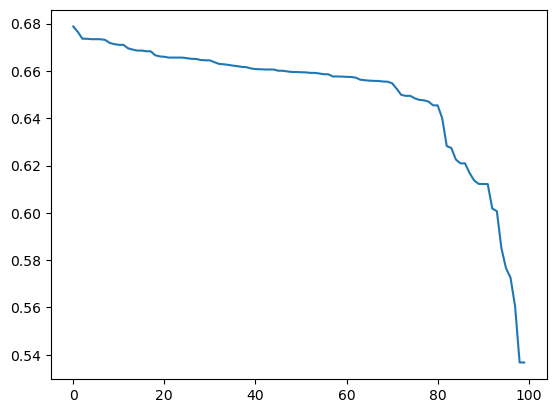

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,param_gamma,param_eval_metric,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,0.573988,0.065719,0.014883,0.000516,0.7,40,100,3,0.2,total_gain,10,auc,20,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.687314,0.675668,0.673408,0.678797,0.006093,1
1,0.364763,0.004504,0.013519,0.000817,0.7,20,20,2,0.2,total_gain,1,auc,50,"{'subsample': 0.7, 'n_estimators': 20, 'min_ch...",0.683983,0.674644,0.670882,0.676503,0.005508,2
2,0.505101,0.003548,0.016042,0.001462,0.7,30,50,3,0.1,total_gain,0.5,auc,20,"{'subsample': 0.7, 'n_estimators': 30, 'min_ch...",0.684249,0.663745,0.672880,0.673624,0.008387,3
3,0.606751,0.057259,0.013524,0.001084,0.9,30,20,3,0.1,total_gain,1,auc,50,"{'subsample': 0.9, 'n_estimators': 30, 'min_ch...",0.680094,0.667534,0.673181,0.673603,0.005136,4
4,0.407216,0.015314,0.012857,0.000240,0.9,20,100,2,0.15,total_gain,0.5,auc,20,"{'subsample': 0.9, 'n_estimators': 20, 'min_ch...",0.682595,0.665962,0.671707,0.673421,0.006898,5


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.5974264705882353

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2023_01_ARI_WAS,1,WAS,ARI,1,0.523227
1,2023_01_ARI_WAS,1,ARI,WAS,0,0.440781
2,2023_01_BUF_NYJ,1,BUF,NYJ,0,0.576183
3,2023_01_BUF_NYJ,1,NYJ,BUF,1,0.407331
4,2023_01_CAR_ATL,1,CAR,ATL,0,0.492517
...,...,...,...,...,...,...
539,2023_18_PIT_BAL,18,BAL,PIT,0,0.646870
540,2023_18_SEA_ARI,18,ARI,SEA,0,0.486222
541,2023_18_SEA_ARI,18,SEA,ARI,1,0.572805
542,2023_18_TB_CAR,18,CAR,TB,0,0.422532


week
1     0.595703
2     0.421875
3     0.515625
4     0.921875
5     0.397959
6     0.644444
7     0.331361
8     0.716797
9     0.755102
10    0.729592
11    0.887755
12    0.509766
13    0.710059
14    0.493333
15    0.792969
16    0.628906
17    0.710938
18    0.558594
dtype: float64

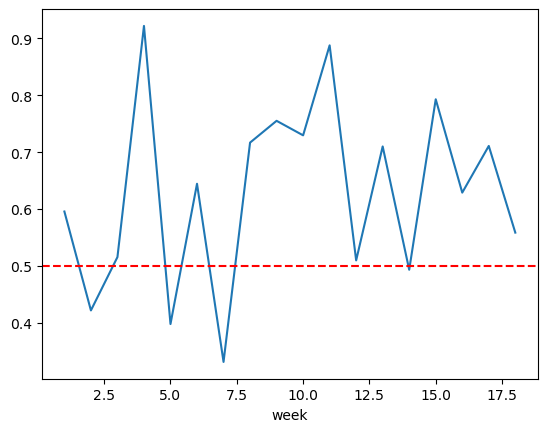

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.608333
2     0.507937
3     0.468750
4     0.846154
5     0.622222
6     0.722222
7     0.300000
8     0.536364
9     0.625000
10    0.600000
11    0.900000
12    0.706349
13    0.433333
14    0.571429
15    0.583333
16    0.555556
17    0.650000
18    0.416667
dtype: float64

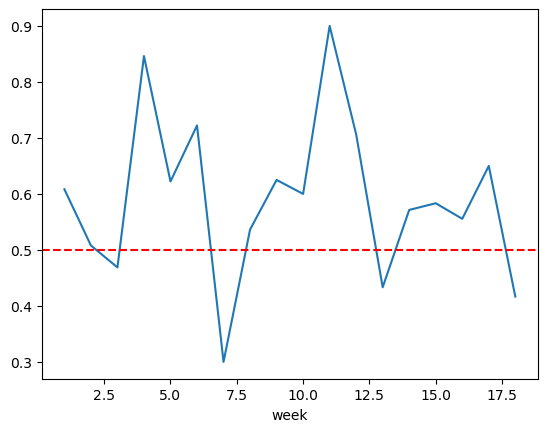

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores